In [1]:
import matplotlib.pyplot as plt
import json
import os


In [2]:
def draw_scatter_all_batch(result_list: list,
                           x_col = 19, y_col=9,
                           y_label = 'y_label', 
                           x_title = "mean_difference", y_title = "acc",
                           result_path = "./result_fig", figname = "test.png",
                           save_fig = True,
                           x_data_dict = {},
                           y_data_dict = {},
                           ):
    # Create a new figure
    # plt.figure()

    # scatter
    # Extract the metric column as x
    x = [row[x_col] for row in result_list]
    x_max = max(abs(x) for x in x)
    x = [x_i/x_max for x_i in x]

    # x_data_dict
    x_data_dict[y_label] = x

    # Extract the acc columns as y
    y = [row[y_col] for row in result_list]

    # y_data_dict
    y_data_dict[y_label] = y

    size_point = max(2, min(1000.0/len(x), 20))
    print(f"draw_scatter(): size_point = {size_point}")
    
    plt.scatter(x, y, label=y_label, s=size_point, alpha=0.8)

    # Add a legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # title
    plt.xlabel(x_title)
    plt.ylabel(y_title)

    # save the plot
    # plt.show()
    if save_fig:
        # test_path_exist(result_path)
        plt.savefig(os.path.join(result_path, figname), bbox_inches='tight')

    # Close the figure
    # plt.close()   

In [3]:
dataset_i_list = [0, 1]
binary_class_index_list = [1, 2, 3, 6, 7, 8]
dataset_name_source_list = ["dwq_sentinel2", "xj_sentinel2"]
dataset_name_target_list = dataset_name_source_list[::-1]

# E:\Yiling\at_SIAT_research\z_result\20241210_transfer_metric_FD_cross_sensor_batch14_FD\20241210_1734_1_dwq_s2_xj_s2_\4_label1_FID_all-batch1_100img
result_path = r"E:\Yiling\at_SIAT_research\z_result\20241210_transfer_metric_FD_cross_sensor_batch14_FD\20241210_1734_1_dwq_s2_xj_s2_\4_label1_FID_all-batch1_100img"
result_list_dict_path = os.path.join(result_path, "result_list_dict_dwq_sentinel2-xj_sentinel2_batch1.json")
with open(result_list_dict_path, 'r') as f:
    result_list_dict = json.load(f)
result_list_name_path = os.path.join(result_path, "result_list_name.json")
with open(result_list_name_path, 'r') as f:
    result_list_name = json.load(f)

for i in range(len(result_list_name)):
    print(f"{i}, {result_list_name[i]}")

0, source
1, target
2, class_index
3, class_name
4, OA_delta
5, F1_delta
6, precision_delta
7, mean_dif_absolute_sum
8, mean_dif_absolute_abs_sum
9, mean_dif_relative_sum
10, mean_dif_relative_abs_sum
11, mean_dif_absolute_y0_y1_diff
12, mean_dif_absolute_abs_y0_y1_diff
13, mean_dif_relative_y0_y1_diff
14, mean_dif_relative_abs_y0_y1_diff
15, mean_dif_absolute_y0_y1_diff_abs
16, mean_dif_absolute_abs_y0_y1_diff_abs
17, mean_dif_relative_y0_y1_diff_abs
18, mean_dif_relative_abs_y0_y1_diff_abs
19, mean_dif_absolute_y0_y1_diff_normalized
20, mean_dif_absolute_abs_y0_y1_diff_normalized
21, mean_dif_relative_y0_y1_diff_normalized
22, mean_dif_relative_abs_y0_y1_diff_normalized
23, mean_dif_absolute_y0_y1_diff_abs_normalized
24, mean_dif_absolute_abs_y0_y1_diff_abs_normalized
25, mean_dif_relative_y0_y1_diff_abs_normalized
26, mean_dif_relative_abs_y0_y1_diff_abs_normalized
27, FD_sum
28, FD_y0_y1_diff
29, FD_y0_y1_diff_abs
30, FD_y0_y1_diff_normalized
31, FD_y0_y1_diff_abs_normalized


draw_scatter(): size_point = 2.8011204481792715
draw_scatter(): size_point = 20
draw_scatter(): size_point = 6.8493150684931505
draw_scatter(): size_point = 15.625
draw_scatter(): size_point = 20
draw_scatter(): size_point = 2
draw_scatter(): size_point = 2.2988505747126435
draw_scatter(): size_point = 2
draw_scatter(): size_point = 20
draw_scatter(): size_point = 5.780346820809249
draw_scatter(): size_point = 2
draw_scatter(): size_point = 5.128205128205129


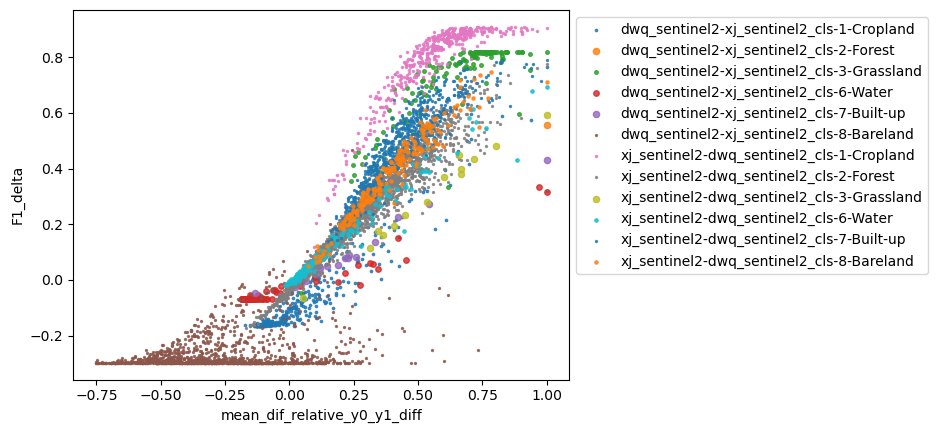

In [4]:
x_data_dict = {}
y_data_dict = {}
# Create a new figure
batch_size = 1
metric_i = 13
accuracy_i = 5
binary_class_name_list = ["background", "Cropland", "Forest", "Grassland", "Shrubland", "Wetland", "Water", "Built-up", "Bareland"]
plt.figure()
for dataset_i in dataset_i_list:
    save_fig = False
    for binary_class_index in binary_class_index_list:
        result_list = result_list_dict[dataset_name_source_list[dataset_i] + f"_cls_{binary_class_index}"]
        # save the last figure
        if binary_class_index == binary_class_index_list[-1]:
            save_fig = True
        draw_scatter_all_batch(result_list, x_col=metric_i, y_col=accuracy_i,
                                y_label=f"{dataset_name_source_list[dataset_i]}-{dataset_name_target_list[dataset_i]}_cls-{binary_class_index}-{binary_class_name_list[binary_class_index]}",
                                x_title=result_list_name[metric_i], y_title=result_list_name[accuracy_i],
                                # result_path=os.path.join("./result_fig", "fig"),
                                figname=f"20241216_1815_test_dwq_s2_xj_s2_batch{batch_size}_cls_{binary_class_index}_{dataset_i}.png",
                                save_fig=save_fig,
                                x_data_dict=x_data_dict,
                                y_data_dict=y_data_dict,
                                )
# plt.close()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 示例数据
data = x_data_dict

# 将数据转换为长格式
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))
df_long = df.melt(var_name='Group', value_name='Value')

# 绘制分布图
sns.histplot(data=df_long, x='Value', hue='Group', element='poly', stat='density', common_norm=False, kde=True)

# 添加标题和标签
plt.title('Distribution of Multiple Datasets with KDE')
plt.xlabel('Value')
plt.ylabel('Density')

# 将图例放到图形外边
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Group')

# 调整图形布局以适应图例
plt.tight_layout()

# 显示图形
plt.show()

In [5]:
def draw_normal_distribution(data, label='legend', plt=plt):
    # Create histogram
    # plt.hist(data, bins=30, density=True, alpha=0.6, label=label)
    # bins = len(data) // 100
    bins = 100
    plt.hist(data, bins='auto', density=True, alpha=0.6, label=label)

dwq_sentinel2-xj_sentinel2_cls-1-Cropland: 357
dwq_sentinel2-xj_sentinel2_cls-2-Forest: 1
dwq_sentinel2-xj_sentinel2_cls-3-Grassland: 146
dwq_sentinel2-xj_sentinel2_cls-6-Water: 64
dwq_sentinel2-xj_sentinel2_cls-7-Built-up: 16
dwq_sentinel2-xj_sentinel2_cls-8-Bareland: 1184
xj_sentinel2-dwq_sentinel2_cls-1-Cropland: 435
xj_sentinel2-dwq_sentinel2_cls-2-Forest: 2045
xj_sentinel2-dwq_sentinel2_cls-3-Grassland: 14
xj_sentinel2-dwq_sentinel2_cls-6-Water: 173
xj_sentinel2-dwq_sentinel2_cls-7-Built-up: 604
xj_sentinel2-dwq_sentinel2_cls-8-Bareland: 195
dwq_sentinel2-xj_sentinel2_cls-1-Cropland: 357
dwq_sentinel2-xj_sentinel2_cls-2-Forest: 1
dwq_sentinel2-xj_sentinel2_cls-3-Grassland: 146
dwq_sentinel2-xj_sentinel2_cls-6-Water: 64
dwq_sentinel2-xj_sentinel2_cls-7-Built-up: 16
dwq_sentinel2-xj_sentinel2_cls-8-Bareland: 1184
xj_sentinel2-dwq_sentinel2_cls-1-Cropland: 435
xj_sentinel2-dwq_sentinel2_cls-2-Forest: 2045
xj_sentinel2-dwq_sentinel2_cls-3-Grassland: 14
xj_sentinel2-dwq_sentinel2_cls-6

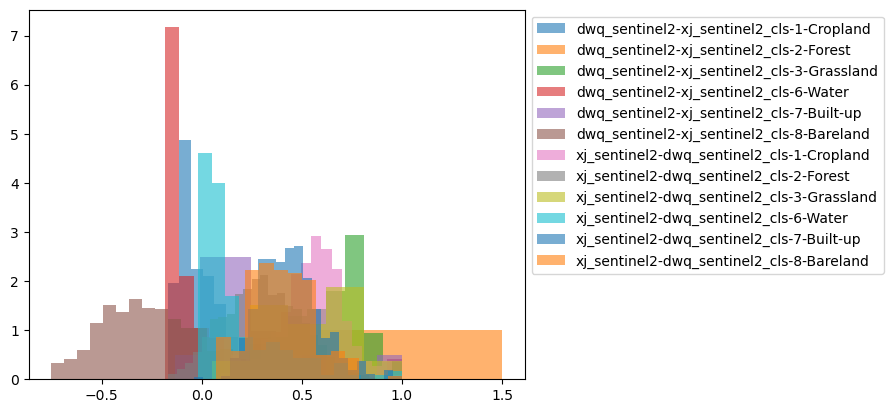

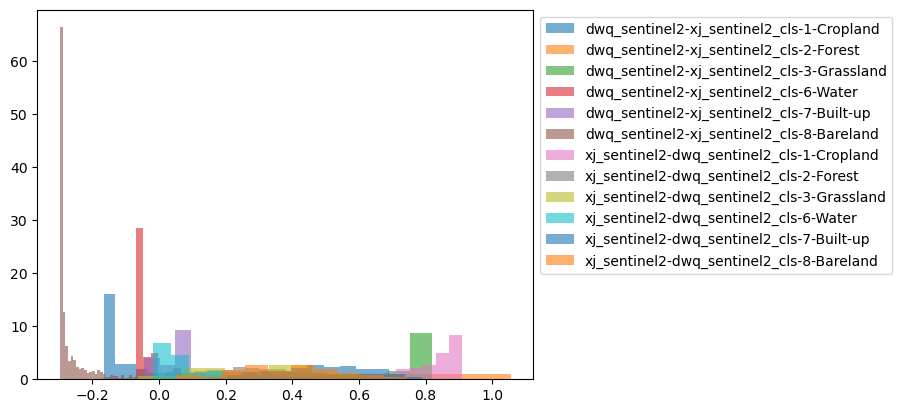

In [6]:
plt.figure()
for key, value in x_data_dict.items():
    draw_normal_distribution(value, label=key)
    print(f"{key}: {len(value)}")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.figure()
for key, value in y_data_dict.items():
    draw_normal_distribution(value, label=key)
    print(f"{key}: {len(value)}")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))


In [7]:
# 度量分数与精度损失的分布关系
# mean, std, max, min, median, 25%, 75%
x_mean_list = []
y_mean_list = []
for key, value in x_data_dict.items():
    x_mean_list.append([key, sum(value)/len(value)])
for key, value in y_data_dict.items():
    y_mean_list.append([key, sum(value)/len(value)])
print(f"x_mean_list: {x_mean_list}")
print(f"y_mean_list: {y_mean_list}")


x_mean_list: [['dwq_sentinel2-xj_sentinel2_cls-1-Cropland', 0.05870198986361196], ['dwq_sentinel2-xj_sentinel2_cls-2-Forest', 1.0], ['dwq_sentinel2-xj_sentinel2_cls-3-Grassland', 0.6238961129534082], ['dwq_sentinel2-xj_sentinel2_cls-6-Water', -0.01783805182456108], ['dwq_sentinel2-xj_sentinel2_cls-7-Built-up', 0.2416583616566392], ['dwq_sentinel2-xj_sentinel2_cls-8-Bareland', -0.2447413931552345], ['xj_sentinel2-dwq_sentinel2_cls-1-Cropland', 0.549711454845484], ['xj_sentinel2-dwq_sentinel2_cls-2-Forest', 0.30507230308681016], ['xj_sentinel2-dwq_sentinel2_cls-3-Grassland', 0.5416747512385058], ['xj_sentinel2-dwq_sentinel2_cls-6-Water', 0.17755091758547842], ['xj_sentinel2-dwq_sentinel2_cls-7-Built-up', 0.43920802723635644], ['xj_sentinel2-dwq_sentinel2_cls-8-Bareland', 0.3996931267390672]]
y_mean_list: [['dwq_sentinel2-xj_sentinel2_cls-1-Cropland', -0.061489726795034914], ['dwq_sentinel2-xj_sentinel2_cls-2-Forest', 0.5563713312149048], ['dwq_sentinel2-xj_sentinel2_cls-3-Grassland', 0.7

draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20
draw_scatter(): size_point = 20


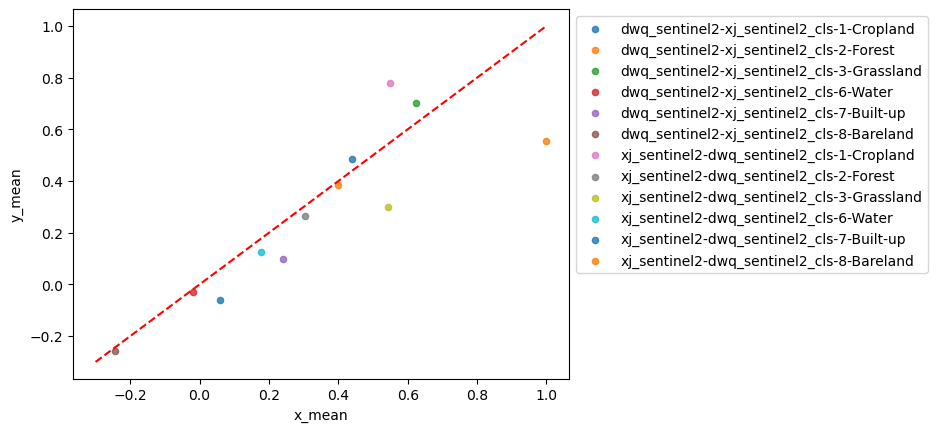

In [8]:
def mean_scatter(x_list: list,
                            y_list: list,
                           x_col = 19, y_col=9,
                           y_label = 'y_label', 
                           x_title = "mean_difference", y_title = "acc",
                           result_path = "./result_fig", figname = "test.png",
                           save_fig = True,
                           ):
    # Create a new figure
    # plt.figure()

    x = [row[x_col] for row in x_list]
    y = [row[y_col] for row in y_list]

    size_point = max(2, min(1000.0/len(x), 20))
    print(f"draw_scatter(): size_point = {size_point}")
    
    plt.scatter(x, y, label=y_label, s=size_point, alpha=0.8)

    # Add a legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # title
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    # plt.show()

plt.figure()
for i in range(len(x_mean_list)):
    mean_scatter([x_mean_list[i]], [y_mean_list[i]], x_col=1, y_col=1, y_label=x_mean_list[i][0], x_title="x_mean", y_title="y_mean")
x = [-0.3, 1.0]
plt.plot(x, x, label='x=y', linestyle='--', color='red')
plt.show()